### Lite Tacotron Text-to-Speech Training Framework

Title:
End-to-End Neural Speech Synthesis with TacotronLite

Short Description:
This code implements a lightweight Tacotron-like model for text-to-speech synthesis. It trains on LJSpeech dataset samples to predict mel-spectrograms from text input using an encoder-decoder architecture with attention, implementing teacher-forced training and periodic model checkpointing.

Key Libraries Used:

    torch/torchaudio: Deep learning framework and audio processing

    pandas: Metadata handling for LJSpeech dataset

    string: Character mapping utilities

    os: File system operations

Code Logic and Flow

High-Level Overview:
The framework processes LJSpeech audio-text pairs through four stages: dataset loading with CSV metadata, text and audio preprocessing, sequence batching with padding, and encoder-decoder training with attention. It outputs mel-spectrogram predictions and saves model checkpoints after each epoch.

Visual FlowChart:

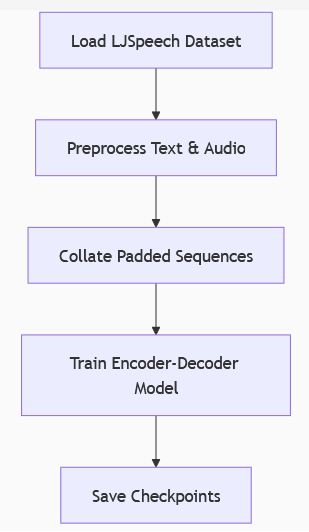

Step-by-Step Code Breakdown

Step 1: Dataset Handling

    Parses LJSpeech metadata CSV with | delimiter

    Matches WAV files to transcripts using filename IDs

    Implements sample limit for quick experimentation

    Handles missing audio files gracefully

Step 2: Preprocessing Pipeline

    Text Processing:

        Converts to lowercase and filters characters

        Maps to numerical sequences with length limiting

    Audio Processing:

        Resamples to 22.05kHz if needed

        Computes 80-band mel-spectrograms

        Configures FFT parameters for speech characteristics

Step 3: Batch Collation

    Pads text sequences to maximum length in batch

    Pads mel-spectrograms to maximum time dimension

    Returns sequence lengths for packed RNN processing

    Maintains original feature dimensions

Step 4: Model Architecture

    Encoder:

        Character embedding layer

        GRU-based sequence encoder

    Decoder:

        GRU-based autoregressive decoder

        Attention mechanism with energy calculation

        Linear projection to mel-spectrogram dimensions

    Uses teacher forcing during training

Step 5: Training Loop

    Employs Mean Squared Error (MSE) loss on mel-spectrograms

    Teacher forcing: inputs previous ground truth frames

    Handles variable-length sequences via packed padding

    Implements error handling for batch failures

    Saves model weights after each epoch

Connecting to the Lecture**

    End-to-End TTS: Demonstrates complete text-to-spectrogram pipeline

    Attention Mechanism: Implements content-based alignment between text and audio

    Teacher Forcing: Shows standard training technique for sequence models

    Feature Engineering: Uses mel-spectrograms as acoustic representation

    Data Handling: Solves real-world metadata parsing challenges

    Lightweight Design: Simplified Tacotron architecture for accessibility

    Sequence Padding: Enables efficient batch processing of variable-length data

    Checkpointing: Preserves training progress for resumption

    Resource Optimization: Limits samples and uses CPU for quick experimentation

    Autoregressive Modeling: Predicts sequential outputs with recurrent decoder

In [4]:
#grok
import os
import torch
import torchaudio
import pandas as pd
import string
from torch import nn
from torch.utils.data import Dataset, DataLoader

# 1. Custom Dataset for LJSpeech with CSV metadata
class MyLJSpeechDataset(Dataset):
    def __init__(self, wavs_dir, metadata_path, max_samples=10):
        df = pd.read_csv(metadata_path, sep='|', header=None)  # Use | as delimiter for LJSpeech CSV
        self.samples = []
        for i, row in df.iterrows():
            if len(self.samples) >= max_samples:
                break
            wav_id = str(row[0]).strip()
            transcript = str(row[1]).strip()  # Use second column for transcript
            wav_path = os.path.join(wavs_dir, f"{wav_id}.wav")
            if os.path.exists(wav_path):
                self.samples.append((wav_path, transcript))
            else:
                print(f"Missing audio: {wav_path}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        wav_path, transcript = self.samples[idx]
        waveform, sr = torchaudio.load(wav_path)
        return waveform, sr, transcript, wav_path

# 2. Preprocessing functions
alphabet = string.ascii_lowercase + " '"
char_to_idx = {c: i+1 for i, c in enumerate(alphabet)}

def text_to_sequence(text, max_len=200):
    seq = [char_to_idx.get(c, 0) for c in text.lower() if c in char_to_idx]
    seq = seq[:max_len]
    return torch.tensor(seq, dtype=torch.long)

def mel_spectrogram(wav, sr=22050, n_mels=80):
    if sr != 22050:
        wav = torchaudio.transforms.Resample(sr, 22050)(wav)
    mel_transform = torchaudio.transforms.MelSpectrogram(
        sample_rate=22050, n_mels=n_mels, n_fft=1024, f_max=8000
    )
    mel = mel_transform(wav)
    return mel.squeeze(0).transpose(0, 1)  # (time, n_mels)

# 3. Custom collate function for padding
def collate_fn(batch):
    waveforms, srs, transcripts, wav_paths = zip(*batch)
    # Texts
    text_seqs = [text_to_sequence(t) for t in transcripts]
    text_lens = [len(seq) for seq in text_seqs]
    max_text_len = max(text_lens)
    text_padded = torch.zeros(len(text_seqs), max_text_len, dtype=torch.long)
    for i, seq in enumerate(text_seqs):
        text_padded[i, :len(seq)] = seq

    # Mels
    mels = [mel_spectrogram(w, sr) for w, sr in zip(waveforms, srs)]
    mel_lens = [mel.shape[0] for mel in mels]
    max_mel_len = max(mel_lens)
    n_mels = mels[0].shape[1]
    mels_padded = torch.zeros(len(mels), max_mel_len, n_mels)
    for i, mel in enumerate(mels):
        mels_padded[i, :mel.shape[0], :] = mel

    return text_padded, torch.tensor(text_lens), mels_padded, torch.tensor(mel_lens)

# 4. DataLoader
WAVS_DIR = r"7 Challenges and Future Directions in SpeechLM Research\7.2 End-to-End Training\LJSpeech-1.1\wavs" # Replace with your filepath
METADATA_PATH = r"7 Challenges and Future Directions in SpeechLM Research\7.2 End-to-End Training\LJSpeech-1.1\metadata.csv" # Replace with your filepath
dataset = MyLJSpeechDataset(WAVS_DIR, METADATA_PATH, max_samples=10)
train_loader = DataLoader(dataset, batch_size=2, collate_fn=collate_fn, num_workers=0)

# 5. Define Lite Tacotron2 Components
class TacotronLite(nn.Module):
    def __init__(self, n_mels, embedding_dim):
        super().__init__()
        self.embedding = nn.Embedding(num_embeddings=100, embedding_dim=embedding_dim)
        self.encoder = nn.GRU(embedding_dim, 64, batch_first=True)
        self.decoder = nn.GRU(n_mels, 64, batch_first=True)
        self.attention = nn.Linear(64, 1)  # Adjusted for element-wise sum of decoder and encoder outputs
        self.mel_head = nn.Linear(64, n_mels)

    def forward(self, text, text_lens, mels_in, mel_lens):
        # Encoder
        embedded = self.embedding(text)
        packed_embedded = nn.utils.rnn.pack_padded_sequence(embedded, text_lens.cpu(), batch_first=True, enforce_sorted=False)
        encoder_out, _ = self.encoder(packed_embedded)
        encoder_out, _ = nn.utils.rnn.pad_packed_sequence(encoder_out, batch_first=True)
        
        # Decoder (teacher-forced)
        decoder_state = None
        outputs = []
        for i in range(mels_in.size(1)):  # iterate over time
            decoder_out, decoder_state = self.decoder(
                mels_in[:, i:i+1, :], 
                decoder_state
            )
            # Attention
            enc_out_exp = encoder_out[:, :decoder_out.size(1), :]
            combined = torch.tanh(decoder_out + enc_out_exp)  # (batch_size, 1, 64)
            energy = self.attention(combined.squeeze(1))  # (batch_size, 1)
            attn_weights = torch.softmax(energy.unsqueeze(1), dim=1)  # (batch_size, 1, 1)
            context = torch.sum(attn_weights * enc_out_exp, dim=1)  # (batch_size, 64)
            
            # Predict next mel
            mel_pred = self.mel_head(context)  # (batch_size, n_mels)
            outputs.append(mel_pred)
        
        return torch.stack(outputs, dim=1)  # (batch_size, time, n_mels)

# 6. Initialize Model
device = torch.device("cpu")
model = TacotronLite(n_mels=80, embedding_dim=64).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
loss_fn = nn.MSELoss()

# 7. Training Loop (10 samples, 5 epochs) with model saving
for epoch in range(5):
    print(f"Starting epoch {epoch}")
    for i, (texts, text_lens, mels, mel_lens) in enumerate(train_loader):
        try:
            texts = texts.to(device)
            text_lens = text_lens.to(device)
            mels = mels.to(device)
            mel_lens = mel_lens.to(device)
            # Teacher-forcing: input all but last frame, target is all but first frame
            mels_in = mels[:, :-1, :]
            mels_target = mels[:, 1:, :]
            pred_mels = model(texts, text_lens, mels_in, mel_lens)
            # Pad pred_mels to match mels_target if needed
            min_len = min(pred_mels.size(1), mels_target.size(1))
            loss = loss_fn(pred_mels[:, :min_len, :], mels_target[:, :min_len, :])
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            print(f"    Epoch {epoch} | Batch {i} | Loss: {loss.item():.4f}")
        except Exception as e:
            print(f"    Error in epoch {epoch}, batch {i}: {e}")
            continue
    # Save model after each epoch
    model_path = os.path.join(r"7.2 End-to-End Training", f"tacotron_epoch_{epoch}.pt") # Replace with your filepath
    torch.save(model.state_dict(), model_path)
    print(f"    Saved model to {model_path}")

Starting epoch 0
    Epoch 0 | Batch 0 | Loss: 28954.0117
    Epoch 0 | Batch 1 | Loss: 81904.2422
    Epoch 0 | Batch 2 | Loss: 25501.3359
    Epoch 0 | Batch 3 | Loss: 29846.4746
    Epoch 0 | Batch 4 | Loss: 43833.2969
    Saved model to C:\Users\vinit_hqjv9wt\Desktop\FinFree Project\Courses\Deep learning for Speech language model\7 Challenges and Future Directions in SpeechLM Research\7.2 End-to-End Training\tacotron_epoch_0.pt
Starting epoch 1
    Epoch 1 | Batch 0 | Loss: 28953.7773
    Epoch 1 | Batch 1 | Loss: 81903.9297
    Epoch 1 | Batch 2 | Loss: 25501.1484
    Epoch 1 | Batch 3 | Loss: 29846.2539
    Epoch 1 | Batch 4 | Loss: 43833.0273
    Saved model to C:\Users\vinit_hqjv9wt\Desktop\FinFree Project\Courses\Deep learning for Speech language model\7 Challenges and Future Directions in SpeechLM Research\7.2 End-to-End Training\tacotron_epoch_1.pt
Starting epoch 2
    Epoch 2 | Batch 0 | Loss: 28953.5840
    Epoch 2 | Batch 1 | Loss: 81903.6562
    Epoch 2 | Batch 2 | Loss: